## 예애 2차과제

#1.로지스틱 회귀모델을 구축하기 위한 데이터를 찾고 어떤 문제를 해결하기 위한 데이터인지 설명하시오. 

--- 데이터 기본 정보 ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), i

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



--- 타겟 변수(Machine failure) 비율 (%) ---
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

--- 세부 고장 모드별 발생 건수 ---
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


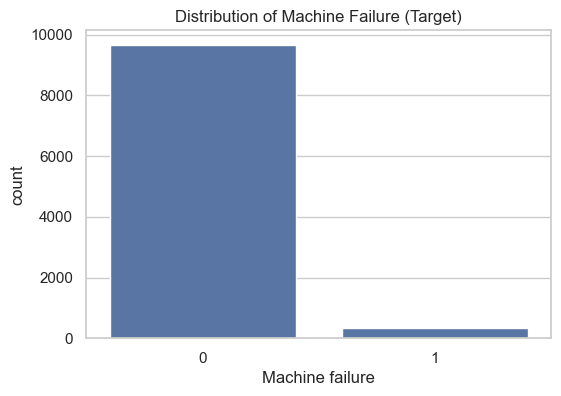

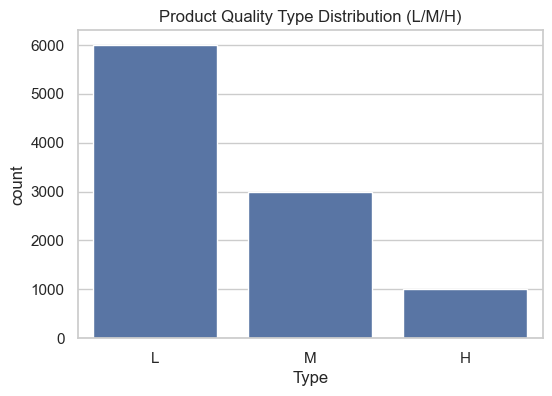

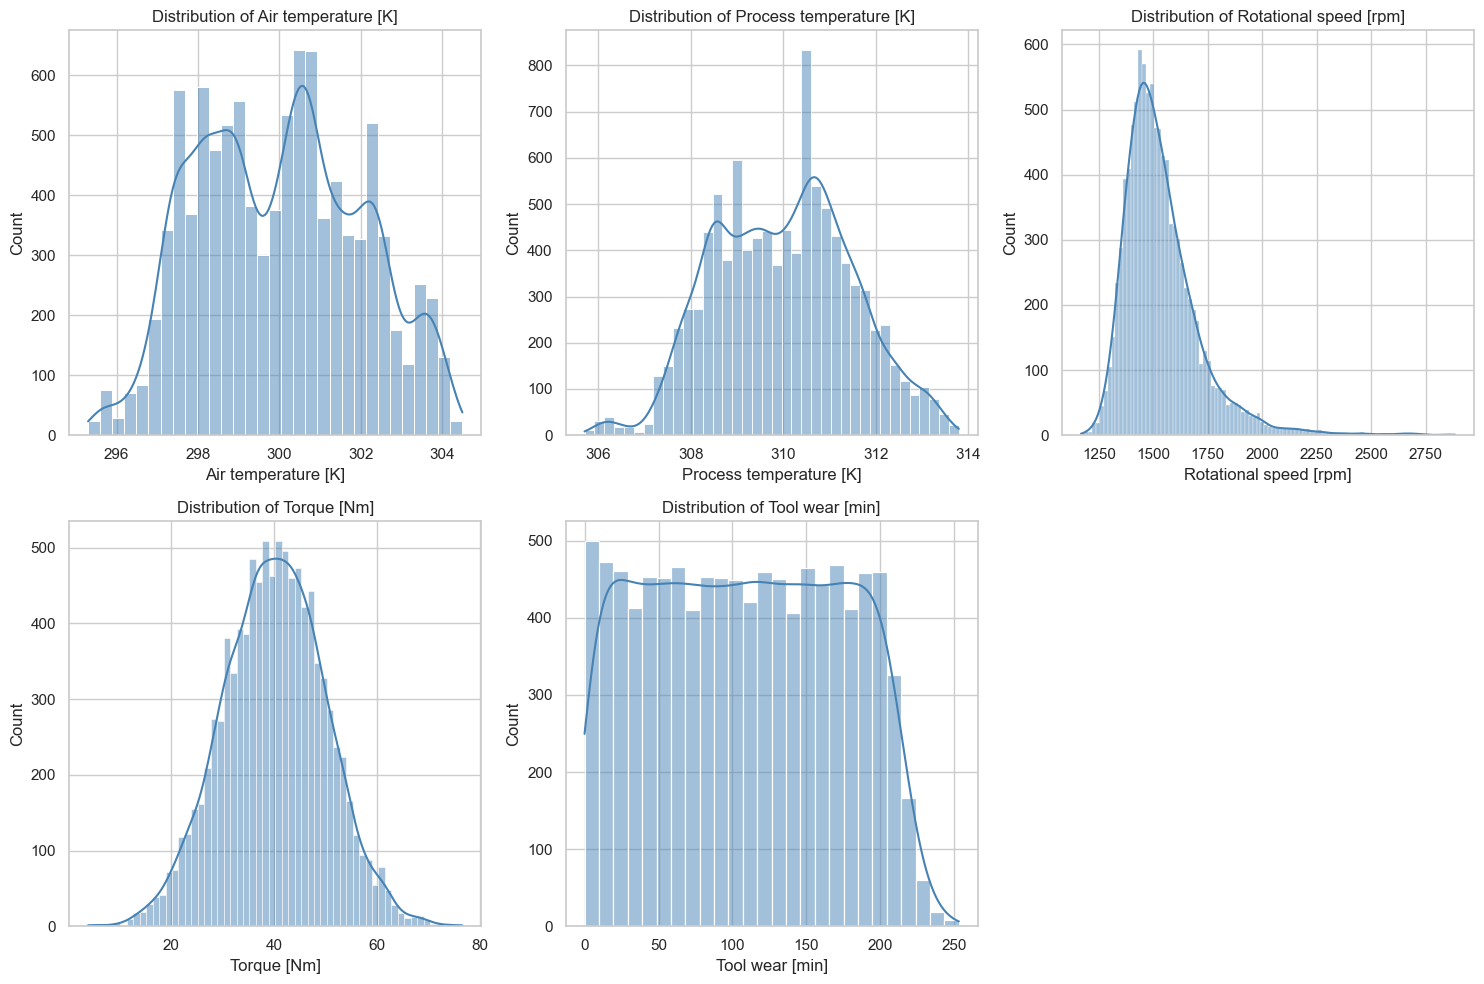

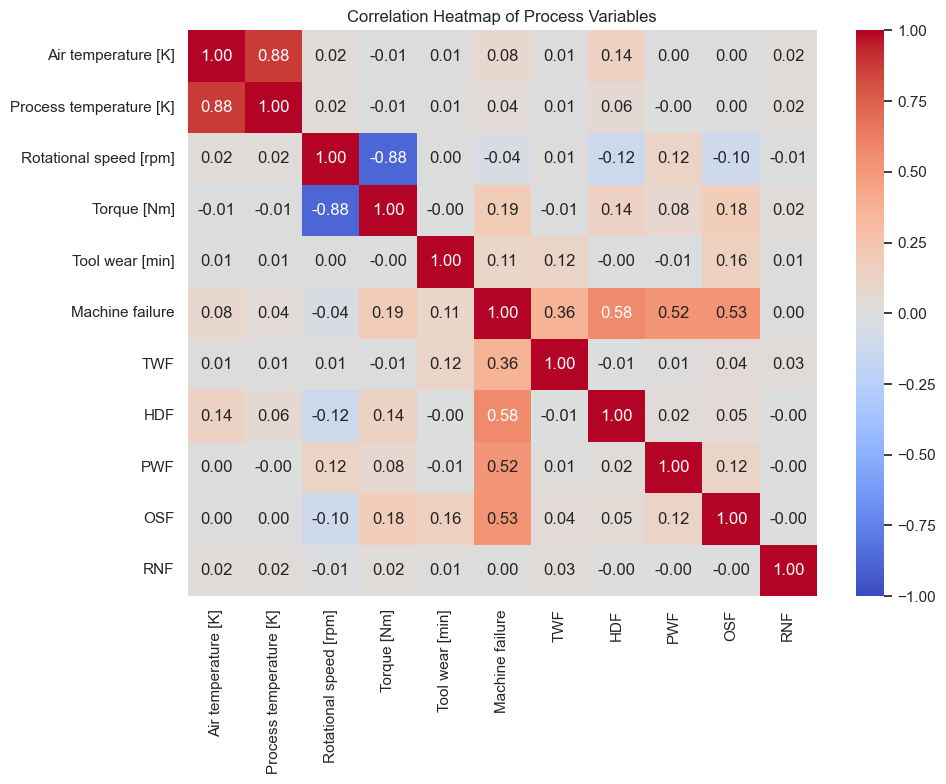

C:\Users\jeiki\AppData\Local\Temp\ipykernel_8740\2344301305.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')


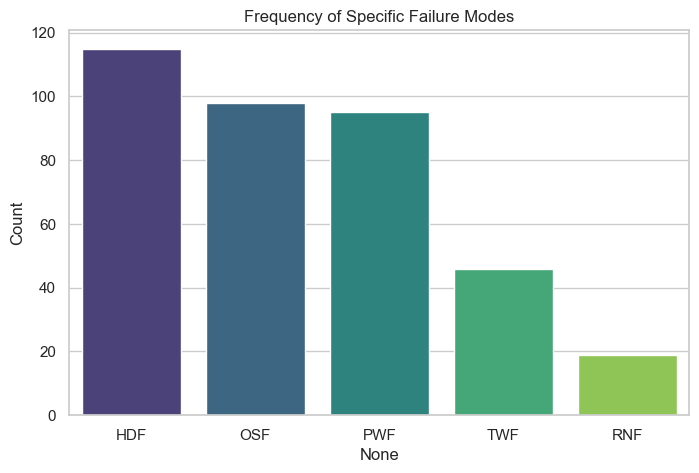

Type
L    235
M     83
H     21
Name: count, dtype: int64


In [ ]:
from shutil import which

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv(r"C:\코딩\예애\2차과제\archive\ai4i2020.csv")

# 2. 기본 정보 및 결측치 확인
print("--- 데이터 기본 정보 ---")
df.info()

print("\n--- 결측치 확인 ---")
print(df.isnull().sum())

print("\n--- 요약 통계량 ---")
display(df.describe())

# 3. 타겟 변수 (Machine failure) 분포 확인 (클래스 불균형 체크)
print("\n--- 타겟 변수(Machine failure) 비율 (%) ---")
print(df['Machine failure'].value_counts(normalize=True) * 100)

# 4. 5가지 세부 고장 모드 발생 건수 확인
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("\n--- 세부 고장 모드별 발생 건수 ---")
print(df[failure_modes].sum())

# ==========================================
# 시각화 (Visualizations)
# ==========================================
sns.set_theme(style="whitegrid")

# 4-1. 타겟 변수(Machine failure) 분포 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution of Machine Failure (Target)')
plt.show()

# 4-2. 제품 품질 등급(Type) 분포 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', order=['L', 'M', 'H'], data=df)
plt.title('Product Quality Type Distribution (L/M/H)')
plt.show()

# 4-3. 핵심 수치형 공정 변수들의 분포 (히스토그램)
num_features = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

# 남는 빈 그래프 공간 숨기기
fig.delaxes(axes[5]) 
plt.tight_layout()
plt.show()

# 4-4. 변수 간 상관관계 히트맵 (다중공선성 확인용)
plt.figure(figsize=(10, 8))
# 수치형 변수와 고장 관련 변수들만 선택하여 상관계수 계산
corr_cols = num_features + ['Machine failure'] + failure_modes
corr_matrix = df[corr_cols].corr()

# 히트맵 그리기 (상관계수가 높을수록 진한 색)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Process Variables')
plt.tight_layout()
plt.show()

# 4-5. 세부 고장 모드 빈도수 시각화
plt.figure(figsize=(8, 5))
failure_counts = df[failure_modes].sum().sort_values(ascending=False)
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Frequency of Specific Failure Modes')
plt.ylabel('Count')
plt.show()

# 'Machine failure'가 1인 데이터의 'Type' 컬럼만 추출
df[df['Machine failure'] == 1]['Type']
# 고장난 제품들의 Type별 개수 세기
print(df.loc[df['Machine failure'] == 1, 'Type'].value_counts())

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 2. 불필요한 변수 및 고장 모드(Target Leakage) 변수 제거 [조건 3]
# UDI, Product ID 및 5가지 세부 고장 모드(TWF, HDF, PWF, OSF, RNF) 삭제
columns_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=columns_to_drop)

# 3. 다중공선성(Multicollinearity) 해결 [조건 1]
# Air temperature [K]와 Process temperature [K] 중 Process temperature를 제거
df_clean = df_clean.drop(columns=['Process temperature [K]'])

# 4. Type 변수를 서열(Ordinal) 수치 데이터로 변환 [조건 2]
# 품질에 따라 L(Low)=1, M(Medium)=2, H(High)=3 으로 매핑
type_mapping = {'L': 1, 'M': 2, 'H': 3}
df_clean['Type'] = df_clean['Type'].map(type_mapping)

# 5. 피처(X)와 타겟(y) 분리
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

# 6. 연속형 변수 스케일링 (Standardization)
# 로지스틱 회귀에서 각 변수의 영향력을 공정하게 비교하기 위해 단위(Scale)를 통일합니다.
# Type은 서열형 척도이므로 스케일링에서 제외합니다.
scaler = StandardScaler()
continuous_features = ['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X_scaled = X.copy()
X_scaled[continuous_features] = scaler.fit_transform(X[continuous_features])

# --- 전처리 결과 확인 ---
print("✅ 전처리 완료!")
print(f"피처 데이터(X) 차원: {X_scaled.shape}")
print(f"타겟 데이터(y) 차원: {y.shape}\n")

print("--- 전처리된 피처 데이터(X) 상위 5개행 ---")
display(X_scaled.head())

✅ 전처리 완료!
피처 데이터(X) 차원: (10000, 5)
타겟 데이터(y) 차원: (10000,)

--- 전처리된 피처 데이터(X) 상위 5개행 ---


,Type,Air temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,-0.952389,0.068185,0.282200,-1.695984
1,1,-0.902393,-0.729472,0.633308,-1.648852
2,1,-0.952389,-0.227450,0.944290,-1.617430
3,1,-0.902393,-0.590021,-0.048845,-1.586009
4,1,-0.902393,-0.729472,0.001313,-1.554588


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. 학습용(Train)과 테스트용(Test) 데이터 분리 (8:2 비율)
# stratify=y : 분리된 데이터에서도 원본의 극심한 불균형 비율(96:4)이 그대로 유지되도록 만듭니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. 로지스틱 회귀 모델 선언
# class_weight='balanced'를 통해 데이터 물리적 조작 없이 손실 함수에서 불균형을 통제합니다.
# max_iter는 모델이 최적해를 찾기 위해 반복하는 최대 횟수로, 안정적인 학습을 위해 넉넉하게 1000으로 설정했습니다.
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 3. 모델 학습 (Training)
lr_model.fit(X_train, y_train)

print("✅ 로지스틱 회귀 모델 학습(Construction)이 완료되었습니다!")
print(f"- 학습에 사용된 훈련 데이터 개수: {len(X_train)}개")
print(f"- 평가를 위해 남겨둔 테스트 데이터 개수: {len(X_test)}개")

✅ 로지스틱 회귀 모델 학습(Construction)이 완료되었습니다!
- 학습에 사용된 훈련 데이터 개수: 8000개
- 평가를 위해 남겨둔 테스트 데이터 개수: 2000개


--- 🎯 분류 성능 평가 (Classification Report) ---
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1932
           1       0.13      0.81      0.23        68

    accuracy                           0.81      2000
   macro avg       0.56      0.81      0.56      2000
weighted avg       0.96      0.81      0.87      2000

▶ ROC-AUC Score: 0.8918



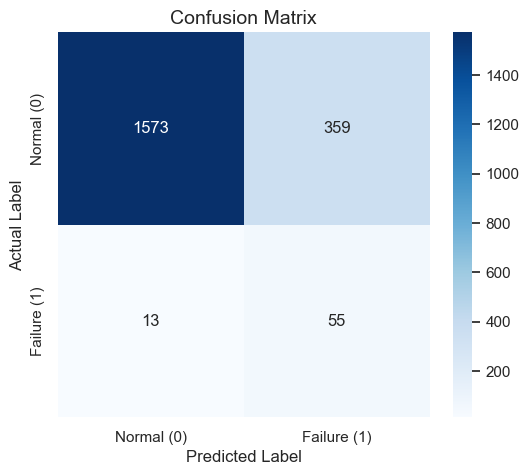

--- 🔍 로지스틱 회귀 오즈비(Odds Ratio) 분석 결과 ---


,Feature,Coefficient,Odds Ratio
0,Torque [Nm],2.303696,10.011118
1,Rotational speed [rpm],1.612440,5.015031
2,Air temperature [K],0.768659,2.156871
3,Tool wear [min],0.764588,2.148108
4,Type,-0.263101,0.768664


C:\Users\jeiki\AppData\Local\Temp\ipykernel_8740\4073962613.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds Ratio', y='Feature', data=or_df, palette='Reds_r')


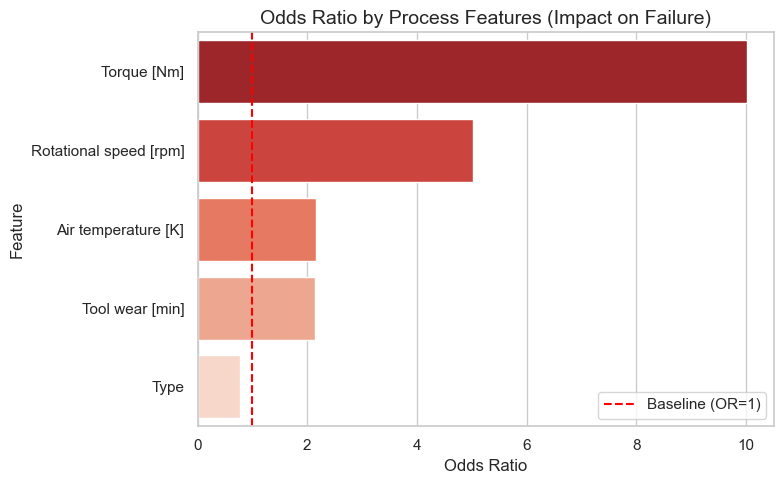

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ==========================================
# 1. 모델 성능 평가 (Evaluation)
# ==========================================
# 테스트 데이터에 대한 예측값 및 예측 확률 도출
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("--- 🎯 분류 성능 평가 (Classification Report) ---")
# 불균형 데이터이므로 Accuracy보다 Precision, Recall, F1-score가 중요합니다.
print(classification_report(y_test, y_pred))

# ROC-AUC 점수 (1에 가까울수록 성능이 좋음)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"▶ ROC-AUC Score: {roc_auc:.4f}\n")

# 혼동 행렬 (Confusion Matrix) 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Failure (1)'], 
            yticklabels=['Normal (0)', 'Failure (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# ==========================================
# 2. 오즈비 (Odds Ratio) 분석 - 품질관리 핵심 포인트!
# ==========================================
# 모델의 회귀 계수(Coefficient, 베타) 추출
coefficients = lr_model.coef_[0]

# 계수에 지수(Exponential)를 취해 오즈비(Odds Ratio) 계산
odds_ratios = np.exp(coefficients)

# 결과를 한눈에 보기 쉽게 DataFrame으로 정리
feature_names = X_train.columns
or_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})

# 오즈비가 높은 순서대로 정렬 (불량에 미치는 영향이 큰 순서)
or_df = or_df.sort_values(by='Odds Ratio', ascending=False).reset_index(drop=True)

print("--- 🔍 로지스틱 회귀 오즈비(Odds Ratio) 분석 결과 ---")
display(or_df)

# 오즈비 시각화 (Feature Importance)
plt.figure(figsize=(8, 5))
sns.barplot(x='Odds Ratio', y='Feature', data=or_df, palette='Reds_r')
plt.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (OR=1)')
plt.title('Odds Ratio by Process Features (Impact on Failure)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### cut-off 조정

--- 📊 Cut-off 값 변화에 따른 성능 변화 ---


,Cut-off,Accuracy,Precision,Recall,F1-Score
0,0.10,0.3470,0.0482,0.9706,0.0918
1,0.15,0.4620,0.0579,0.9706,0.1093
2,0.20,0.5465,0.0671,0.9559,0.1254
3,0.25,0.6050,0.0753,0.9412,0.1394
4,0.30,0.6595,0.0853,0.9265,0.1561
5,0.35,0.7055,0.0936,0.8824,0.1693
6,0.40,0.7460,0.1029,0.8382,0.1833
7,0.45,0.7870,0.1208,0.8382,0.2111
8,0.50,0.8140,0.1329,0.8088,0.2282
9,0.55,0.8460,0.1512,0.7647,0.2524



✅ F1-Score 기준 최적의 Cut-off 값: 0.80
▶ 이 때의 성능 | Accuracy: 0.9490, Precision: 0.3396, Recall: 0.5294


c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\코딩\예애\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: Us

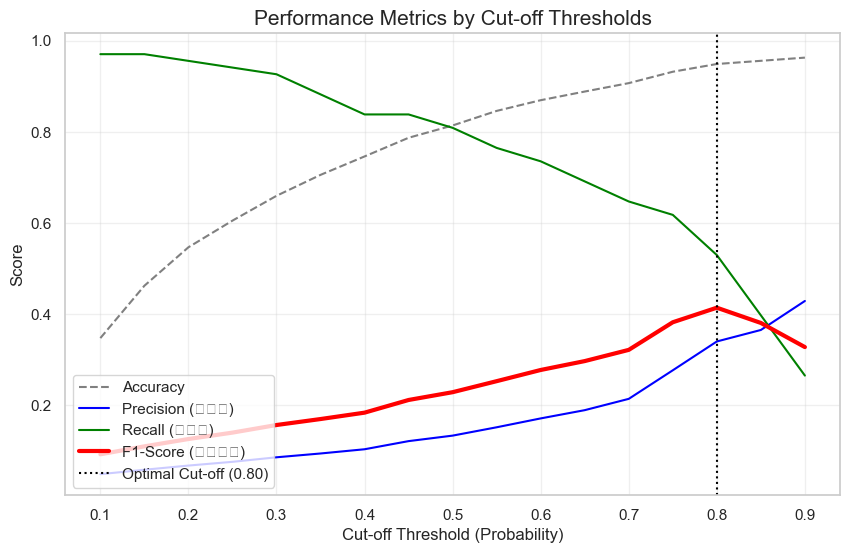

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 테스트 데이터에 대한 예측 확률 추출 (Target이 1(불량)일 확률)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# 2. Cut-off 값 후보군 설정 (0.1 부터 0.9까지 0.05 간격으로 탐색)
thresholds = np.arange(0.1, 0.95, 0.05)

# 결과를 저장할 리스트 초기화
accuracies = []
precisions = []
recalls = []
f1_scores = []

# 3. 각 Cut-off 값에 대해 성능 지표 계산
for threshold in thresholds:
    # 확률이 threshold 이상이면 1(불량), 아니면 0(정상)으로 분류
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    
    accuracies.append(accuracy_score(y_test, y_pred_custom))
    precisions.append(precision_score(y_test, y_pred_custom, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_custom))
    f1_scores.append(f1_score(y_test, y_pred_custom))
    
# 데이터프레임으로 결과 정리
results_df = pd.DataFrame({
    'Cut-off': thresholds,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

# 4. 최적의 Cut-off 값 찾기 
# 불균형 데이터이므로 F1-Score(정밀도와 재현율의 조화평균)가 가장 높은 곳을 찾습니다.
optimal_idx = results_df['F1-Score'].idxmax()
optimal_threshold = results_df.loc[optimal_idx, 'Cut-off']

print("--- 📊 Cut-off 값 변화에 따른 성능 변화 ---")
display(results_df.round(4))

print(f"\n✅ F1-Score 기준 최적의 Cut-off 값: {optimal_threshold:.2f}")
print(f"▶ 이 때의 성능 | Accuracy: {results_df.loc[optimal_idx, 'Accuracy']:.4f}, Precision: {results_df.loc[optimal_idx, 'Precision']:.4f}, Recall: {results_df.loc[optimal_idx, 'Recall']:.4f}")

# 5. 성능 변화 시각화 (Trade-off 그래프)
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label='Accuracy', linestyle='--', color='gray')
plt.plot(thresholds, precisions, label='Precision (정밀도)', color='blue')
plt.plot(thresholds, recalls, label='Recall (재현율)', color='green')
plt.plot(thresholds, f1_scores, label='F1-Score (조화평균)', linewidth=3, color='red')

# 최적의 Cut-off 위치에 수직선 그리기
plt.axvline(optimal_threshold, color='black', linestyle=':', 
            label=f'Optimal Cut-off ({optimal_threshold:.2f})')

plt.title('Performance Metrics by Cut-off Thresholds', fontsize=15)
plt.xlabel('Cut-off Threshold (Probability)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()